GOAL: test the equations coupling and the variable timestep.

L'équation de dissolution d'un mineral traceur et de l'évolution des concentrations s'écrit:

$$
  \forall n \in [0, N], \left\{
    \begin{array}{l}
      \overline{c}_{i}^{2n+1} = \overline{c}_{i}^{2n}
      \\\\
      \mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{2n+1} - c_{i}^{2n}}{\Delta t^{2n}} = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{2n+1} - c_{i}^{2n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big)
      \\\\
      \overline{c}_{i}^{2n+2} = \overline{c}_{i}^{2n+1} + \Delta t^{2n} k_{v} A_{s} \overline{c}_{i}^{2n+1} \left( 1 - \dfrac{c_{i}^{2n+1}}{K_{s}}\right)
      \\\\
      c_{i}^{2n+2} = c_{i}^{2n+1} - \left(\overline{c}_{i}^{2n+2} - \overline{c}_{i}^{2n+1}\right)
    \end{array}
  \right.
$$

En fait il vaut mieux écrire:

$$
  \forall n \in [0, N], \left\{
    \begin{array}{l}
      \mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{n+1} - c_{i}^{n}}{\Delta t^{n}} = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) - \left(\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}\right)
      \\\\
      \overline{c}_{i}^{n+1} = \overline{c}_{i}^{n} + \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
    \end{array}
  \right.
$$

Note that $N$ is the number of timesteps, in total, there are $N+1$ states and $n=0$ is the initial state.

$$ \mathcal{L} = \dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{2n, \mathrm{obs}} - c_{i}^{2n, \mathrm{calc}}}{\sigma_{c_{i}}^{2n, \mathrm{obs}}}\right)^{2} - \langle \lambda_{c_{i}}^{n+1}, g_{c}^{n+1} \rangle_{n \in [0, N]} - \langle \lambda_{c_{i}}^{n}, g_{c}^{n} \rangle_{n \in [0, N]} - \langle \lambda_{\overline{c}_{i}}^{n+1}, g_{\overline{c}}^{n+1} \rangle_{n \in [0, N]} - \langle \lambda_{\overline{c}_{i}}^{n}, g_{\overline{c}}^{n} \rangle_{n \in [0, N]} $$

Written explicitely, it reads:

\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{2n, \mathrm{obs}} - c_{i}^{2n, \mathrm{calc}}}{\sigma_{c_{i}}^{2n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{2n+1} \Bigg[ \overline{c}_{i}^{2n+1} - \overline{c}_{i}^{2n}\Bigg] 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{2n+1} \Bigg[ \mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{2n+1} - c_{i}^{2n}}{\Delta t^{2n}} - \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{2n+1} - c_{i}^{2n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) \Bigg]
\\ 
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{2n+2} \Bigg[\overline{c}_{i}^{2n+2} - \overline{c}_{i}^{2n+1} - \Delta t^{2n} k_{v} A_{s} \overline{c}_{i}^{2n+1} \left( 1 - \dfrac{c_{i}^{2n+1}}{K_{s}}\right)
 \Bigg]  
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{2n+2}\Bigg[c_{i}^{2n+2} - c_{i}^{2n+1} + \overline{c}_{i}^{2n+2} - \overline{c}_{i}^{2n+1} \Bigg]
\end{aligned}
\end{equation}    


Very important remark for the derivation: $\overline{c}_{i}^{2n}$ and $\overline{c}_{i}^{2n+1}$ are two independant variables. Same for $c_{i}^{2n}$ and $c_{i}^{2n+1}$, no matter $n$, it is never overlapping.

## 1) Derivation by $\overline{c}_{i}^{2n}$:

Only the second and the thrid scalar products have terms that depends on $\overline{c}_{i}^{2n}$ (or $\overline{c}_{i}^{2n+2}$), the lagrangian derivative reads:
$$
\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{2n}} =
\begin{cases}
    \lambda_{\overline{c}_{i}}^{1}, & \text{if}\ n = 0 
    \\\\
    \lambda_{\overline{c}_{i}}^{2n+1} - \lambda_{\overline{c}_{i}}^{2n} - \lambda_{c_{i}}^{2n}, & \forall n \in [1, N] 
    \\\\
    - \lambda_{\overline{c}_{i}}^{2n+2} - \lambda_{c_{i}}^{2n+2}, & \text{if}\ n = N+1
\end{cases}
$$

Since we want to impose $\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{2n}} = 0$, it gives the initial condition for the adjoint state:

$$ \lambda_{\overline{c}_{i}}^{2N+2} = - \lambda_{c_{i}}^{2N+2}$$

And the temporal evolution:
$$\lambda_{\overline{c}_{i}}^{2n} = \lambda_{\overline{c}_{i}}^{2n+1} - \lambda_{c_{i}}^{2n}, \forall n \in [1, N] $$



In addition we have the gradient with respect to $\overline{c}_{i}^{0}$

## 2) Derivation by $\overline{c}_{i}^{2n+1}$:


Only the second and the thrid scalar products have terms that depends on $\overline{c}_{i}^{2n+1}$, the lagrangian derivative reads:
$$
\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{2n+1}} =
\begin{cases}
    - \lambda_{\overline{c}_{i}}^{2n+1} + \lambda_{\overline{c}_{i}}^{2n+2} \left(1 + \Delta t^{2n}  k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{2n+1}}{K_{s}}\right)\right) + \lambda_{c_{i}}^{2n+2}, & \forall n \in [0, N] \
    \\
    0, & \text{if}\ n = N+1
\end{cases}
$$

So we obtain the adjoint equation:

$$  \lambda_{\overline{c}_{i}}^{2n+1} = \lambda_{\overline{c}_{i}}^{2n+2} \left(1 + \Delta t^{2n}  k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{2n+1}}{K_{s}}\right)\right) + \lambda_{c_{i}}^{2n+2} , \forall n \in [0, N] $$

Note that we don't really care about 

## 3) Derivation by $c_{i}^{2n}$:

$$
\dfrac{\partial \mathcal{L}}{\partial c_{i}^{2n}} =
\begin{cases}
    - \lambda_{c_{i}}^{1} (1 + D_{i}) - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}}, & \text{if}\ n = 0 
    \\\\
    - \dfrac{c_{i}^{2n, \mathrm{obs}} - c_{i}^{2n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{2n, \mathrm{obs}}\right)^{2}} + \dfrac{\lambda_{c_{i}}^{2n+1}}{\Delta t^{2n}} \mathcal{A}_{i}\omega_{i} - \lambda_{c_{i}}^{2n}, & \forall n \in [1, N] 
    \\\\
    - \dfrac{c_{i}^{2N+2, \mathrm{obs}} - c_{i}^{2N+2, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{2N+2, \mathrm{obs}}\right)^{2}} - \lambda_{c_{i}}^{2N+2} , & \text{if}\ n = N+1
\end{cases}
$$

In addition to the gradient on the initial mobile concentration, we obtain the initial condition on the adjoint variable:

$$ \lambda_{c_{i}}^{2N+2} = - \dfrac{c_{i}^{2N+2, \mathrm{obs}} - c_{i}^{2N+2, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{2N+2, \mathrm{obs}}\right)^{2}} $$

And the temporal evolution:


$$\lambda_{c_{i}}^{2n} = \dfrac{\lambda_{c_{i}}^{2n+1}}{\Delta t^{2n}} \mathcal{A}_{i}\omega_{i} - \dfrac{c_{i}^{2n, \mathrm{obs}} - c_{i}^{2n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{2n, \mathrm{obs}}\right)^{2}}, \forall n \in [1, N]$$

## 4) Derivation by $c_{i}^{2n+1}$:

\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{2n, \mathrm{obs}} - c_{i}^{2n, \mathrm{calc}}}{\sigma_{c_{i}}^{2n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{2n+1} \Bigg[ \overline{c}_{i}^{2n+1} - \overline{c}_{i}^{2n}\Bigg] 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{2n+1} \Bigg[ \mathcal{A}_{i} \omega_{i} \dfrac{c_{i}^{2n+1} - c_{i}^{2n}}{\Delta t^{2n}} - \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{c_{j}^{2n+1} - c_{i}^{2n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big) \Bigg]
\\ 
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{2n+2} \Bigg[\overline{c}_{i}^{2n+2} - \overline{c}_{i}^{2n+1} - \Delta t^{2n} k_{v} A_{s} \overline{c}_{i}^{2n+1} \left( 1 - \dfrac{c_{i}^{2n+1}}{K_{s}}\right)
 \Bigg]  
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{2n+2}\Bigg[c_{i}^{2n+2} - c_{i}^{2n+1} + \overline{c}_{i}^{2n+2} - \overline{c}_{i}^{2n+1} \Bigg]
\end{aligned}
\end{equation}    

$$
\dfrac{\partial \mathcal{L}}{\partial c_{i}^{2n+1}} =
\begin{cases}
    - \dfrac{\lambda_{c_{i}}^{2n+1}}{\Delta t^{2n}} + \lambda_{c_{i}}^{2n+2} - \lambda_{\overline{c}_{i}}^{2n+2} \Delta t^{2n} k_{v} A_{s} \overline{c}_{i}^{2n+1} \dfrac{1}{K_{s}} + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(D_{e, ij}\dfrac{\lambda_{c_{j}}^{2n+1} - \lambda_{c_{i}}^{2n+1}}{ \left\lVert \overrightarrow{P_{i}P_{j}} \right\rVert}\big), & \forall n \in [0, N] 
    \\\\
    0 , & \text{if}\ n = N+1
\end{cases}
$$

Then:

$$ \lambda_{c_{i}}^{2n+1} = \lambda_{c_{i}}^{2n+2} - \lambda_{\overline{c}_{i}}^{2n+2} \Delta t^{2n} k_{v} A_{s} \overline{c}_{i}^{2n+1} \dfrac{1}{K_{s}}, \forall n \in [0, N]$$

## Numerical tests

In [1]:
from typing import List
import numpy as np
import matplotlib.pyplot as plt
import numpy.typing as npt
import numdifftools as nd
from pyrtid.utils.finite_differences import finite_gradient

In [2]:
NDArrayFloat = npt.NDArray[np.float_]

In [3]:
class GeochemicalParameters:
    """
    Class defining the geocgemical parameters used in the simulation.

    Attributes
    ----------
    conc: float, optional
        Initial tracer concentration in the grid in molal. The default is 0.0.
    grade: float, optional
        Default mineral grade in the grid in mol/kg (kg of water).
        The default is 0.0.
    kv: float, optional
        The kinetic rate of the mineral in [mol/m2/s]. The default is -6.9e-9.
    As: float, optional
        Specific area in [m2/mol]. The default is 13.5.
    Ks: float, optional
        Solubility constant (no unit). The default is 6.3e-4.
    """

    def __init__(
        self,
        conc: float = 0.0,
        grade: float = 0.0,
        kv: float = -6.9e-9,
        As: float = 13.5,
        Ks: float = 6.3e-4,
    ) -> None:
        """Initialize the instance."""
        self.conc: float = conc
        self.grade: float = grade
        self.kv: float = kv
        self.As: float = As
        self.Ks: float = Ks


class Geometry:
    """
    Class defining the grid geometry used in the simulation.

    Attributes
    ----------
    nx : int
        Number of voxels along the x axis.
    ny : int
        Number of voxels along the y axis.
    dx : float
        Voxel dimension along the x axis.
    dy : float
        Voxel dimension along the y axis.
    dz : float
        Voxel dimension along the z axis. This is only taken into account for
        the voxel volume computation.
    """

    def __init__(
        self,
        nx: int,
        ny: int,
        dx: float,
        dy: float,
        dz: float = 1.0,
    ) -> None:
        """Initialize the class instance."""
        self._nx = 1
        self._ny = 1
        self.nx = int(nx)
        self.ny = int(ny)
        self.dx: float = dx
        self.dy: float = dy
        self.dz: float = dz

    @property
    def nx(self) -> int:
        """Return the number of meshes along the x axis."""
        return self._nx

    @nx.setter
    def nx(self, value: int) -> None:
        if value < 1:
            raise (ValueError("nx should be > 1!)"))
        self._nx = value

    @property
    def ny(self) -> int:
        """Return the number of meshes along the y axis."""
        return self._ny

    @ny.setter
    def ny(self, value: int) -> None:
        self._ny = value

    @property
    def mesh_area(self) -> float:
        """Return the area of a voxel in m2."""
        return self.dx * self.dy

    @property
    def mesh_volume(self) -> float:
        """Return the volume of a voxel in m3."""
        return self.mesh_area * self.dz


class TimeParameters:
    """
    Class defining the time parameters used in the simulation.

    It also handles the variable timestep.

    Attributes
    ----------
    nt : int
        Number of timesteps in the simulation.
    dt : float
        Current timestep in seconds.
    dt_init : float
        Initial timestep in seconds.
    dt_min : float
        Minimum timestep in seconds.
    dt_max : float
        Maximum timestep in seconds.
    ldt: List[float]
        List of successive timesteps (in seconds) used in the forward modelling.
    """

    __slots__ = ["nt", "dt", "dt_init", "dt_min", "dt_max", "ldt"]

    def __init__(self, nt: int, dt_init: float, dt_min: float, dt_max: float) -> None:
        """Initialize the instance."""
        self.nt: int = int(nt)
        self.dt_init: float = dt_init
        self.dt: float = dt_init
        self.dt_min: float = dt_min
        self.dt_max: float = dt_max
        self.ldt: List[float] = []

    @property
    def duration(self) -> float:
        """Simulation duration in seconds."""
        return self.nt * self.dt

    def reset_dt(self) -> None:
        """Empty the list of timesteps and set dt to its initial value."""
        self.dt = self.dt_init
        self.ldt = []

    def update_dt(self, n_iter: int) -> None:
        """
        Update the timestep.

        Parameters
        ----------
        n_iter: int
            Number of iterations required to solve the current timestep.
        """
        if n_iter < 20:
            # increase dt by 5%
            self.dt *= 1.05
        else:
            # decrease dt by 30%
            self.dt *= 0.7
        # Ensure timebounds
        if self.dt < self.dt_min:
            self.dt = self.dt_min
        if self.dt > self.dt_max:
            self.dt = self.dt_max
        self.ldt.append(self.dt)


class TransportParameters:
    """
    Class defining the transport parameters used in the simulation.

    Attributes
    ----------
    diffusion: float, optional
        Default diffusion coefficient in the grid in [m2/s]. The default is 1e-4 m2/s.
    porosity: float, optional
        Default porosity in the grid Should be a number between 0 and 1.
        The default is 1.0.
    crank_nicolson: float
        The Crank-Nicholson parameter allows to set the temporal resolution
        scheme to explicit, fully implicit or somewhere in between these two
        extremes. The value must be comprised between 0.0 and 1.0, 0.0 being a
        full explicit scheme and 1.0 fully implicit. The default is 0.5.
    tolerance: float, optional
        The tolerance on the transport. The default is 1e-8.
    is_numerical_acceleration: bool, optional
        Whether to use the concentration values at the previous iteration as an initial
        guess for gmres (x0) rather than using a random vector. This should increase the
        speed of resolution. The default is False.
    """

    def __init__(
        self,
        diffusion: float = 1e-4,
        porosity: float = 1.0,
        crank_nicolson_advection: float = 0.5,
        crank_nicolson_diffusion: float = 1.0,
        tolerance: float = 1e-8,
        is_numerical_acceleration: bool = False,
    ) -> None:
        """Initialize the instance."""
        self.diffusion: float = diffusion
        self.porosity: float = porosity
        self.crank_nicolson_advection: float = crank_nicolson_advection
        self.crank_nicolson_diffusion: float = crank_nicolson_diffusion
        self.tolerance: float = tolerance
        self.is_numerical_acceleration: bool = is_numerical_acceleration

In [4]:
nx = 20  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 2.98  # voxel dimension along the x axis
dy = 3.7  # voxel dimension along the y axis
dz = 1

geom = Geometry(nx, ny, dx, dy, dz)

# variable timestep
time_params = TimeParameters(
    nt=50,  # number of time steps
    dt_init=5000.0,  # timestep in seconds
    dt_min=500000.0,
    dt_max=5000000.0,
)

# fixed timestep -> comment to get variable timesteps
# time_params = TimeParameters(
#     nt=50,  # number of time steps
#     dt_init=500000.0,  # timestep in seconds
#     dt_min=500000.0,
#     dt_max=500000.0,
# )

# Chemistry parameters
c0 = 0.0001  # general initial concentration [molal]
M0 = 0.001  # mineral grade [mol/kg] -> kg of water
M1 = 0.0005  # mineral grade [mol/kg] -> kg of water
M1 = np.abs(0.001 * (0.5 + 0.5 * np.sin(np.arange(nx) / 2))).reshape(20, -1)
kv = -6.9e-9  # kinetic rate,       [mol/m2/s]
moleweight = 270.0  # molar weight [g/mol]
surface = 500  # cm2/g
As = moleweight * surface / 1e4  # specific area [m2/mol]
logK = 3.2
Ks = 1.0 / pow(10, logK)  # solubility constant [no unit]
porosity = 0.23
diffusion = 0.05

gch_params_ref = GeochemicalParameters(c0, M0, kv, As, Ks)

gch_params_est = GeochemicalParameters(c0, M1, kv, As, Ks)

tr_params = TransportParameters(diffusion=diffusion, porosity=porosity)

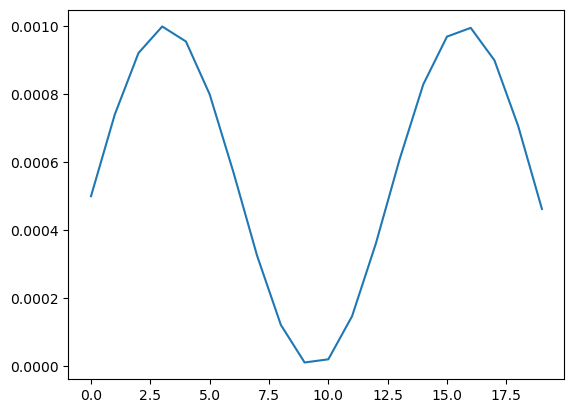

In [5]:
plt.plot(M1)

In [6]:
class TransportModel:
    def __init__(
        self, nt: int, geochem: GeochemicalParameters, tr_params: TransportParameters
    ) -> None:
        self.conc = np.zeros((nx, ny, nt + 1))
        self.conc_post_tr = np.zeros((nx, ny, nt + 1))
        self.conc[:, :, 0] = geochem.conc
        self.conc_post_tr[:, :, 0] = geochem.conc
        self.grade = np.zeros((nx, ny, nt + 1))
        self.grade_post_tr = np.zeros((nx, ny, nt + 1))
        self.grade[:, :, 0] = geochem.grade
        self.grade_post_tr[:, :, 0] = geochem.grade
        self.porosity = np.zeros((nx, ny))
        self.porosity[:, :] = tr_params.porosity
        self.diffusion = np.zeros((nx, ny))
        self.diffusion[:, :] = tr_params.diffusion


class AdjointTransportModel:
    def __init__(self, nt: int) -> None:
        self.a_conc = np.zeros((nx, ny, nt + 1))
        self.a_conc_post_gch = np.zeros((nx, ny, nt + 1))
        self.a_conc_post_tr = np.zeros((nx, ny, nt + 1))
        self.a_grade = np.zeros((nx, ny, nt + 1))
        self.a_grade_post_gch = np.zeros((nx, ny, nt + 1))

In [7]:
def solve_transport(
    tr_model: TransportModel,
    time_index: int,
) -> None:
    """Compute the geochemistry part."""

    # Need to take into account boundary conditions:
    # And then the reactive (chemistry) contribution with the updated conc

    # Note: the concentration has been modified by the transport so we need to use the
    # updated one.
    tr_model.grade_post_tr[:, :, time_index] = tr_model.grade[:, :, time_index - 1]
    tr_model.conc_post_tr[:, :, time_index] = (1 + tr_model.diffusion) * tr_model.conc[
        :, :, time_index - 1
    ]


def solve_geochem_explicit(
    tr_model: TransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    time_index: int,
) -> None:
    """Compute the geochemistry part."""

    # Need to take into account boundary conditions:
    # And then the reactive (chemistry) contribution with the updated conc

    # Note: the concentration has been modified by the transport so we need to use the
    # updated one.
    # m0 = tr_model.grade_post_tr[:, :, time_index]
    m0 = tr_model.grade_post_tr[:, :, time_index]
    c0 = tr_model.conc_post_tr[:, :, time_index]

    dMdt = gch_params.kv * gch_params.As * m0 * (1.0 - c0 / gch_params.Ks)

    tr_model.grade[:, :, time_index] = m0 + dMdt * time_params.dt
    tr_model.conc[:, :, time_index] = c0 - dMdt * time_params.dt

In [8]:
tr_model_ref = TransportModel(time_params.nt, gch_params_ref, tr_params)
tr_model_est = TransportModel(time_params.nt, gch_params_est, tr_params)


def solve_forward(tr_model: TransportModel, gch_params: GeochemicalParameters) -> None:
    time_params.reset_dt()
    for it in range(1, time_params.nt + 1):
        time_params.update_dt(1)  # we consider only one iteration.
        solve_transport(tr_model, it)
        solve_geochem_explicit(tr_model, gch_params, time_params, it)


solve_forward(tr_model_ref, gch_params_ref)
solve_forward(tr_model_est, gch_params_est)

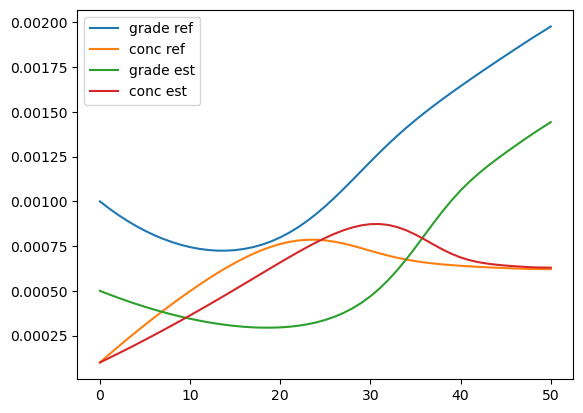

In [9]:
import matplotlib.pyplot as plt

plt.plot(tr_model_ref.grade[0, 0, :], label="grade ref")
plt.plot(tr_model_ref.conc[0, 0, :], label="conc ref")
plt.plot(tr_model_est.grade[0, 0, :], label="grade est")
plt.plot(tr_model_est.conc[0, 0, :], label="conc est")
plt.legend()

In [10]:
def solve_adj_geochem_explicit(
    tr_model: TransportModel,
    a_tr_model: AdjointTransportModel,
    gch_params: GeochemicalParameters,
    geometry: Geometry,
    a_sources,
    time_params: TimeParameters,
    time_index: int,
) -> None:
    # Adjoint variables
    am_prev = a_tr_model.a_grade[:, :, time_index + 1]
    ac_prev = a_tr_model.a_conc[:, :, time_index + 1]
    # Forward variables
    m_prev_post_tr = tr_model.grade_post_tr[:, :, time_index + 1]
    c_prev_post_tr = tr_model.conc_post_tr[:, :, time_index + 1]
    # Timesteps
    dt_cur = time_params.ldt[time_index]

    # Update concentration
    a_tr_model.a_conc_post_gch[:, :, time_index] += (
        ac_prev
        - am_prev
        * dt_cur
        * gch_params.kv
        * gch_params.As
        * m_prev_post_tr
        / gch_params.Ks
    )

    # Update mineral value
    a_tr_model.a_grade_post_gch[:, :, time_index] = (
        am_prev
        * (
            1
            + gch_params.kv
            * gch_params.As
            * (1.0 - c_prev_post_tr / gch_params.Ks)
            * dt_cur
        )
        + ac_prev
    )


def solve_adj_transport(
    tr_model: TransportModel,
    a_tr_model: AdjointTransportModel,
    geometry: Geometry,
    a_sources: NDArrayFloat,
    time_index: int,
) -> None:
    # This works
    a_tr_model.a_conc[:, :, time_index] = (
        a_tr_model.a_conc_post_gch[:, :, time_index] * (1 + tr_model.diffusion)
        - a_sources[:, :, time_index]
    )
    a_tr_model.a_grade[:, :, time_index] = (
        a_tr_model.a_grade_post_gch[:, :, time_index]
        - a_tr_model.a_conc[:, :, time_index]
    )

In [11]:
tr_model_est.porosity[:, :].shape

(20, 1)

In [12]:
atr_model = AdjointTransportModel(time_params.nt)


def get_a_sources(
    tr_model_ref: TransportModel, tr_model_est: TransportModel
) -> NDArrayFloat:
    _out = tr_model_ref.conc - tr_model_est.conc
    # Modify here to remove some of the adjoint variables
    # _out[:, :, 2:] = 0.0
    return _out


_a_sources = get_a_sources(tr_model_ref, tr_model_est)

# Initialize the adjoint variables
atr_model.a_conc[:, :, -1] -= _a_sources[:, :, -1]
atr_model.a_grade[:, :, -1] = -atr_model.a_conc[:, :, -1]

for it in range(time_params.nt - 1, -1, -1):
    # add_chem_adjoint_sources(tr_model_est, atr_model, geom, _a_sources, time_params, it)
    solve_adj_geochem_explicit(
        tr_model_est, atr_model, gch_params_est, geom, _a_sources, time_params, it
    )
    solve_adj_transport(tr_model_est, atr_model, geom, _a_sources, it)


# copy the last values
# atr_model.a_conc[:, :, 0] = atr_model.a_conc_post_gch[:, :, 0]
# atr_model.a_grade[:, :, 0] = atr_model.a_grade[:, :, 0]

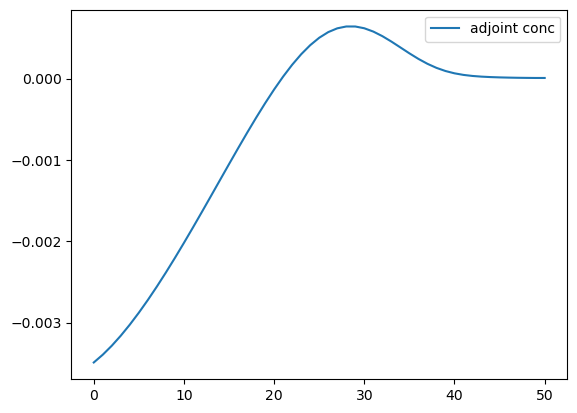

In [13]:
plt.plot(atr_model.a_conc[0, 0, :], label="adjoint conc")
plt.legend()

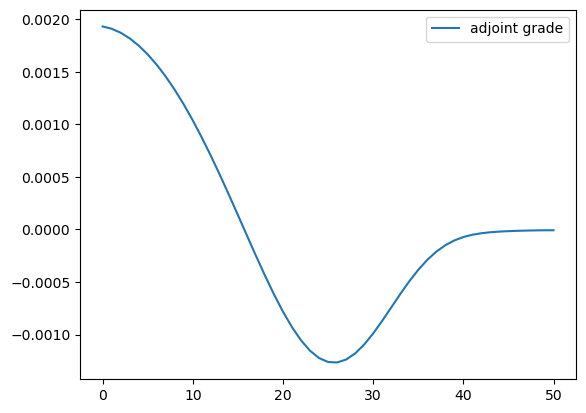

In [14]:
plt.plot(atr_model.a_grade[0, 0, :], label="adjoint grade")
plt.legend()

# Gradient computation

In [15]:
gch_params = gch_params_est


def get_gradient(time_params: TimeParameters):
    return atr_model.a_grade_post_gch[:, :, 0]


adjoint_gradient = get_gradient(time_params=time_params).ravel()
adjoint_gradient

array([-1.55931705e-03, -4.31272225e-04, -8.63677734e-05, -1.15443387e-06,
       -4.59055903e-05, -2.88367748e-04, -1.10034829e-03, -3.60285203e-03,
       -1.07161171e-02,  1.93070552e-03,  1.97473642e-03, -9.07814757e-03,
       -3.03842481e-03, -9.10396205e-04, -2.30067355e-04, -3.04287625e-05,
       -4.94633105e-06, -1.15120093e-04, -5.29228639e-04, -1.86892926e-03])

- Objective function definition

In [16]:
def objfun(x, time_params: TimeParameters) -> float:
    _tr_model = TransportModel(time_params.nt, gch_params_est, tr_params)
    _tr_model.grade[:, :, 0] = x.reshape(nx, ny, order="F")
    solve_forward(_tr_model, gch_params_est)

    _a_sources = get_a_sources(tr_model_ref, _tr_model)
    return float(0.5 * np.sum(_a_sources**2))

- Evaluate the objective function for the initial guess

In [17]:
objfun(M1, time_params)

1.160537047399617e-05

- Define a step for the finite differences

In [18]:
import sys

eps = sys.float_info.epsilon * 1e6
eps

2.220446049250313e-10

- We check the gradients by finite differences (with pyrtid and numdifftools, it is supposed to give the same results, the main difference is that pyrtid supports parallel running.)

In [19]:
def objfun_wrapper(x: NDArrayFloat) -> float:
    return objfun(x, time_params)


fd_gradient_numdifftools = nd.Gradient(objfun_wrapper, step=eps)(M1.ravel("F"))
fd_gradient_pyrtid = finite_gradient(
    np.array([M1]).ravel("F"), objfun, fm_args=(time_params,), eps=eps
)

- Plot the gradients

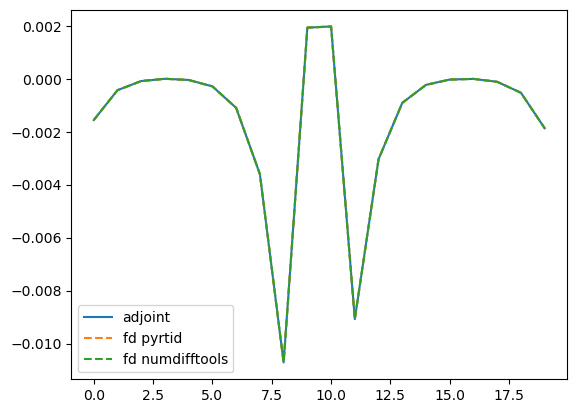

In [20]:
plt.plot(adjoint_gradient, label="adjoint")
plt.plot(fd_gradient_pyrtid, label="fd pyrtid", linestyle="--")
plt.plot(fd_gradient_numdifftools, label="fd numdifftools", linestyle="--")
plt.legend()

- Plot the residuals

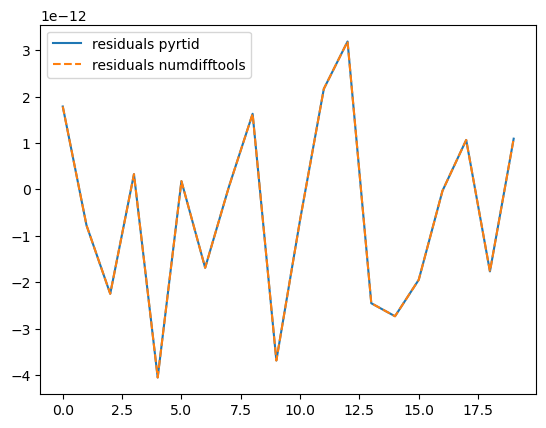

In [21]:
plt.plot((adjoint_gradient - fd_gradient_pyrtid), label="residuals pyrtid")
plt.plot(
    (adjoint_gradient - fd_gradient_numdifftools),
    linestyle="--",
    label="residuals numdifftools",
)
plt.legend()